# Problem 31 — Coin Sums

In the United Kingdom the currency is made up of pound (£) and pence (p). There are eight coins in general circulation:

1p, 2p, 5p, 10p, 20p, 50p, £1 (100p), and £2 (200p).

It is possible to make £2 in the following way:

1×£1 + 1×50p + 2×20p + 1×5p + 1×2p + 3×1p

How many different ways can £2 be made using any number of coins?

In [ ]:
# nice to learn dynamic programming problem

coin_sum = 200
coins = [1,2,5,10,20,50,100,200]

ways = [0] * (coin_sum+1)
ways[0] = 1


for i in range(len(coins)):
    for j in range(len(ways)):
        if coins[i] <= j:
            ways[j] += ways[(int)(j-coins[i])]
            
print(ways[-1])

73682


# Problem 32 — Pandigital Products

We shall say that an n-digit number is pandigital if it makes use of all the digits 1 to n exactly once; for example, the 5-digit number, 15234, is 1 through 5 pandigital.

The product 7254 is unusual, as the identity, 39 × 186 = 7254, contains the multiplicand, multiplier, and product is 1 through 9 pandigital.

Find the sum of all products whose multiplicand/multiplier/product identity can be written as a 1 through 9 pandigital.

**HINT:** Some products can be obtained in more than one way so be sure to only include it once in your sum.

In [9]:
def ispandigital(string):
    if len(string) != 9:
        return False
    
    ch = "".join(sorted(string))
    
    if (ch == "123456789"):
        return True
    else:
        return False

def Pandigital_Product_1_9(n): 
    
    i = 1
    while i * i <= n:
        
        if ((n % i == 0) and
             ispandigital(str(n) + str(i) + str(n // i))) == True:
            return True
            
        i += 1
    
    return False


feasable_products = []

for i in range(1, 98766):
    if Pandigital_Product_1_9(i) == True:
        feasable_products.append(i)
    
    


In [11]:
print(feasable_products)
print(sum(feasable_products))

[4396, 5346, 5796, 6952, 7254, 7632, 7852]
45228


# Problem 33 — Digit Cancelling Fractions

The fraction 49/98 is a curious fraction, as an inexperienced mathematician in attempting to simplify it may incorrectly believe that 49/98 = 4/8, which is correct, is obtained by cancelling the 9s.

We shall consider fractions like, 30/50 = 3/5, to be trivial examples.

There are exactly four non-trivial examples of this type of fraction, less than one in value, with two digits in the numerator and denominator.

If the product of these four fractions is given in its lowest common terms, find the value of the denominator.

In [ ]:
# let's think of it as ab / cd where I want to exclude the trivial examples so a, b, c, d != 0 

to_remove = [i for i in range(10,100,10)]


# possible fractions
nums_33 = [i for i in range(10,100) if i not in to_remove]
n_33 = []
d_33 = []

# numerator < denominator (because fractions have to be >1)
for num in nums_33:
    for den in nums_33:
        if num >= den:
            continue
        a, b = list(map(int, str(num)))
        c, d = list(map(int, str(den)))
        
        if a == c and num * d == den * b:
            n_33.append(b)
            d_33.append(d)
        if a == d and num * c == den * b:
            n_33.append(b)
            d_33.append(c)
        if b == c and num * d == den * a:
            n_33.append(a)
            d_33.append(d)
        if b == d and num * c == den * a:
            n_33.append(a)
            d_33.append(c)
               


In [ ]:
for n, d in zip(n_33, d_33):
    print(f"{n}/{d}")
    
import math
gcd_33 = math.gcd(math.prod(n_33), math.prod(d_33))
# we get 8 / 800 and GCD is 8
print(math.prod(d_33) // gcd_33)
# 800 / 8 = 100 :) 

1/4
1/5
2/5
4/8
100


# Problem 34 — Digit Factorials

145 is a curious number, as 1! + 4! + 5! = 1 + 24 + 120 = 145.

Find the sum of all numbers which are equal to the sum of the factorial of their digits.

**Note:** As 1! = 1 and 2! = 2 are not sums they are not included.

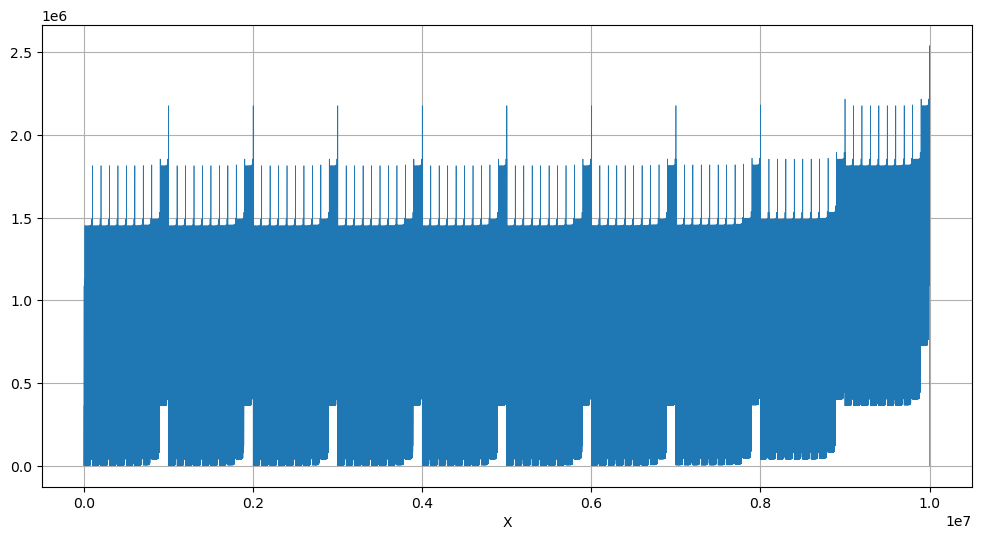

In [7]:
#check for the upper bound

import matplotlib.pyplot as plt
import math
def f(x):
    return sum(math.factorial(int(c)) for c in str(x))
x = range(0, 10000001)
y = [f(i) for i in x]
plt.figure(figsize=(12, 6))
plt.plot(x, y, linewidth=0.5)
plt.xlabel("X")
plt.grid(True)

plt.show()

In [ ]:
# visualization is nice but let's check the numbers themselves

# 7-digit number
print(f(9999999))

# 8-digit number
print(f(99999999))

# 9-digit number
print(f(999999999))

# i wouldn't go beyond the 7-digit number - the sums are not growing much beyond that 

2540160
2903040
3265920


In [12]:
f_of_dig = []

for i in range(10, f(9999999)+1):
    if i == f(i):
        f_of_dig.append(i)
        
print(f_of_dig)

[145, 40585]


In [13]:
print(sum(f_of_dig))

40730


# Problem 35 — Circular Primes

The number, 197, is called a circular prime because all rotations of the digits: 197, 971, 719, are themselves prime.

There are thirteen such primes below 100: 2, 3, 5, 7, 11, 13, 17, 31, 37, 71, 73, 79, and 97.

How many circular primes are there below one million?

In [ ]:
def isPrime(n):
    if n < 2:
        return False
    for i in range(2,int(n**0.5)+1):
        if n%i==0:
            return False
        
    return True

# 5 also cannot be here but i just left 5 here for simplicity of the function 
def oddDigits(n):
    for i in list(map(int, str(n))):
        if i%2==0:
            return False

    return True

def rotate_digits(num):
    rotations = [num]
    num_list = [c for c in str(num)]
    for i in range(1, len(num_list)):
        rotations.append(int(''.join(num_list[i:] + num_list[:i])))


    return rotations


In [51]:
circ_primes = [2]

for i in range(1,1000001):
    if isPrime(i) == True and oddDigits(i) == True:
        rots = rotate_digits(i)
        if all(isPrime(y) for y in rots) == True:
            circ_primes.append(i)

In [ ]:
print(circ_primes)
print(len(circ_primes))

[2, 3, 5, 7, 11, 13, 17, 31, 37, 71, 73, 79, 97, 113, 131, 197, 199, 311, 337, 373, 719, 733, 919, 971, 991, 1193, 1931, 3119, 3779, 7793, 7937, 9311, 9377, 11939, 19391, 19937, 37199, 39119, 71993, 91193, 93719, 93911, 99371, 193939, 199933, 319993, 331999, 391939, 393919, 919393, 933199, 939193, 939391, 993319, 999331]
55


# Problem 36 — Double-base Palindromes

The decimal number, 585 = 1001001001₂ (binary), is palindromic in both bases.

Find the sum of all numbers, less than one million, which are palindromic in base 10 and base 2.

**(Please note that the palindromic number, in either base, may not include leading zeros.)**

In [1]:
def isPalindrome(n):
    res = list(map(int, str(n)))
    last_to_1st = []
    for i in res[::-1]:
        last_to_1st.append(i)
    if res == last_to_1st:
        return True
    else:
        return False

In [20]:
ans_36 = []
for i in range(1, 1000001):
    if isPalindrome(i) == True:
        if isPalindrome(int(format(i, 'b'))) == True:
            ans_36.append(i)
    else:
        continue
  
print(sum(ans_36))      

872187


# Problem 37 — Truncatable Primes

The number 3797 has an interesting property. Being prime itself, it is possible to continuously remove digits from left to right, and remain prime at each stage: 3797, 797, 97, 7. Similarly we can work from right to left: 3797, 379, 37, 3.

Find the sum of the only eleven primes that are both truncatable from left to right and right to left.

**NOTE:** 2, 3, 5, and 7 are not considered to be truncatable primes.

In [39]:
def isPrime(n):
    if n < 2:
        return False
    for i in range(2,int(n**0.5)+1):
        if n%i==0:
            return False
        
    return True

# # Convert number to list of integers
# digits = list(map(int, str(50)))

# # 1. Convert each number to a string
# # 2. Join them together
# # 3. Cast the final string to an integer
# result = int("".join(map(str, digits)))

[5, 0] 50


In [37]:
n = 3797
lis = []

digits = list(map(int, str(n)))
while len(digits) > 0:
    lis.append(int("".join(map(str,digits))))
    digits.pop(-1)
    
digits = list(map(int, str(n)))
while len(digits) >0:
    lis.append(int("".join(map(str,digits))))
    digits.pop(0)

In [ ]:
n = 11 #next prime after 7 
primes_37 = []
lis = []

while len(primes_37) != 11:
    digits = list(map(int, str(n)))
    while len(digits) > 0:
        lis.append(int("".join(map(str,digits))))
        digits.pop(-1)
    
    digits = list(map(int, str(n)))
    while len(digits) >0:
        lis.append(int("".join(map(str,digits))))
        digits.pop(0)
    
    lis = list(set(lis))
    if all(isPrime(y) for y in lis) == True:
        primes_37.append(n)
    lis = []
    n += 1
    while isPrime(n) == False:
        n +=1
    
print(sum(primes_37))  
    

In [44]:
print(primes_37)
print(sum(primes_37))

[23, 37, 53, 73, 313, 317, 373, 797, 3137, 3797, 739397]
748317


# Problem 38 — Pandigital Multiples

Take the number 192 and multiply it by each of 1, 2, and 3:

192 × 1 = 192  
192 × 2 = 384  
192 × 3 = 576  

By concatenating each product we get the 1 to 9 pandigital, 192384576. We will call 192384576 the concatenated product of 192 and (1,2,3).

The same can be achieved by starting with 9 and multiplying by 1, 2, 3, 4, and 5, giving the pandigital, 918273645, which is the concatenated product of 9 and (1,2,3,4,5).

What is the largest 1 to 9 pandigital 9-digit number that can be formed as the concatenated product of an integer with (1,2,...,n) where n > 1?

In [1]:
def isPandigital(n):
    if len(list(map(int, str(n)))) != 9:
        return False
    if list(set(list(map(int, str(n))))) == [1, 2, 3, 4, 5, 6, 7, 8, 9]:
        return True
    else:
        return False

def firstDigit(n):
    while n >= 10: 
        n = n / 10
    return int(n)


In [2]:
# we look for the largest number so we only take into account numbers starting with 9
mults = [1, 2, 3, 4, 5, 6, 7, 8, 9]
nrs = list(range(1,10000))
nrs = [x for x in nrs if firstDigit(x) == 9]
ans_38 = []

for nr in nrs:
    for i in range(0,10):
        x = ""
        for mul in mults[0:i+1]:
            x += str(nr * mul)
        if isPandigital(int(x)):
            ans_38.append(int(x))
        

In [3]:
print(max(ans_38))

932718654


# Problem 39 — Integer Right Triangles

If p is the perimeter of a right angle triangle with integral length sides, {a, b, c}, there are exactly three solutions for p = 120:

{20,48,52}, {24,45,51}, {30,40,50}

For which value of p ≤ 1000, is the number of solutions maximised?

In [29]:
# a + b + c = p 
# a^2 + b^2 = c^2 

# a^2 + b^2 = p^2 + a^2 + b^2 - 2pa - 2pb + 2ab 
#   2pa + 2pb - 2ab = p^2
#   (p^2 - 2pa) / 2(p-a) = b

# smallest is 3,4,5 (p = 12)
triangles = []
counts = {}

for p in range(12, 1001):
    counts[p] = 0
    for a in range(1, p//2+1):
        if (p**2 - 2*p*a) % (2*p - 2*a) == 0:
            b = (p**2 - 2*p*a) // (2*p - 2*a)
            c = p - a - b
        else:
            continue
        if a**2 + b**2 == c**2 and a > 0 and b > 0 and c > 0 and b>a:
            triangles.append([a, b, c])
            counts[p] += 1
        
    

In [ ]:
ans_39 = max(counts, key=counts.get)
print(ans_39)




840
0


# Problem 40 — Champernowne's Constant

An irrational decimal fraction is created by concatenating the positive integers:

0.123456789**1**0111213141516171819202122...

It can be seen that the 12th digit of the fractional part is 1.

If dₙ represents the nth digit of the fractional part, find the value of the following expression:

d₁ × d₁₀ × d₁₀₀ × d₁₀₀₀ × d₁₀₀₀₀ × d₁₀₀₀₀₀ × d₁₀₀₀₀₀₀

In [54]:
# digits:
    # 1 digit = 9 * 1 
    # 2 digit = 90 * 2 
    # 3 digit = 900 * 3 
    # 4 digit = 9000 * 4
    # 5 digit = 90000 * 5
    # 6 digit = 900000 * 6
    # total 5888889 digits

# suma = 9 * (1 + 10*2 + 100*3 + 1000*4 + 10000*5 + 100000*6)
# print(suma)

fraction_list = []

for n in range(1, 1000000):
    digits = list(map(int, str(n)))
    for digit in digits:
        fraction_list.append(digit)
        
indexes = [0, 9, 99, 999, 9999, 99999, 999999]

ans_40 = 1
for indx in indexes:
    ans_40 *= fraction_list[indx]
    
print(ans_40)

210


210
